In [1]:
%pip install --upgrade pip

%pip install \
    numpy \
    pandas \
    matplotlib \
    datasets \
    transformers \
    torch \
    tqdm \
    ipywidgets

%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/shutil.py", line 853, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/bin/torchfrtrace' -> '/tmp/pip-uninstall-i4n_1c67/torchfrtrace'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/roman/.local/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 109, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/home/roman/.local/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 10

In [2]:
# imports
import re
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

import torch
from collections import Counter
from torch.utils.data import Dataset, DataLoader

import math
import time
import torch.nn as nn

import pandas as pd

SEED = 42

Размер train: 23767
Размер val: 2461
Размер test: 2891

Примеры текстов:

--- Пример 1 ---
= Valkyria Chronicles III =

--- Пример 2 ---
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and fo

--- Пример 3 ---
The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Honjou and composer Hitoshi Sakimoto both return

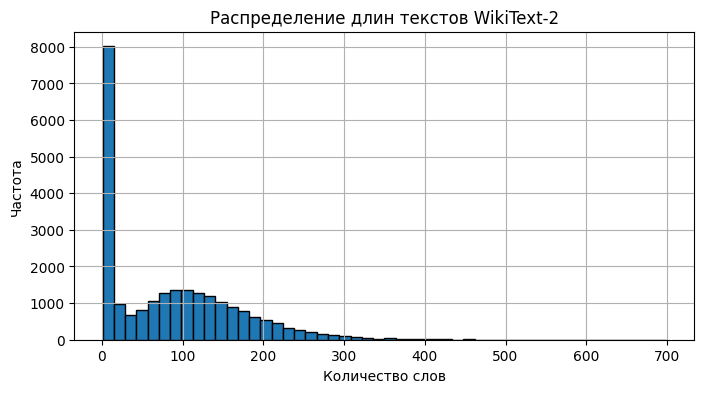

In [3]:
# этап 1. Загрузка и подготовка данных
np.random.seed(SEED)

# Загрузка WikiText-2
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

train_texts = dataset["train"]["text"]
val_texts = dataset["validation"]["text"]
test_texts = dataset["test"]["text"]

# Убираем пустые строки
train_texts = [text.strip() for text in train_texts if text.strip()]
val_texts = [text.strip() for text in val_texts if text.strip()]
test_texts = [text.strip() for text in test_texts if text.strip()]

print("Размер train:", len(train_texts))
print("Размер val:", len(val_texts))
print("Размер test:", len(test_texts))

print("\nПримеры текстов:")
for i in range(5):
    print(f"\n--- Пример {i + 1} ---")
    print(train_texts[i][:500])

# Простая оценка числа предложений
def count_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

# Длины в словах
word_lengths = [len(text.split()) for text in train_texts]
sentence_counts = [count_sentences(text) for text in train_texts]

print("\nСтатистика по длинам текстов в словах:")
print("Средняя длина:", np.mean(word_lengths))
print("Медиана:", np.median(word_lengths))
print("Минимум:", np.min(word_lengths))
print("Максимум:", np.max(word_lengths))
print("95-й перцентиль:", np.percentile(word_lengths, 95))

print("\nСтатистика по числу предложений:")
print("Всего предложений:", sum(sentence_counts))
print("Среднее число предложений на строку:", np.mean(sentence_counts))

plt.figure(figsize=(8, 4))
plt.hist(word_lengths, bins=50, edgecolor="black")
plt.title("Распределение длин текстов WikiText-2")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

In [4]:
# этап 1. Загрузка и подготовка данных
MIN_FREQ = 2
SEQ_LEN = 32
BATCH_SIZE = 64

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_ID = 0
UNK_ID = 1


def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


# Токенизация train
train_tokens = []

for text in train_texts:
    train_tokens.extend(tokenize(text))

print("Всего токенов в train:", len(train_tokens))

# Словарь по train
counter = Counter(train_tokens)

vocab = {
    PAD_TOKEN: PAD_ID,
    UNK_TOKEN: UNK_ID,
}

for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

id_to_word = {idx: word for word, idx in vocab.items()}

print("Размер словаря:", len(vocab))


def encode_texts(texts, vocab):
    ids = []

    for text in texts:
        tokens = tokenize(text)

        for token in tokens:
            ids.append(vocab.get(token, UNK_ID))

    return ids


train_ids = encode_texts(train_texts, vocab)
val_ids = encode_texts(val_texts, vocab)
test_ids = encode_texts(test_texts, vocab)

print("train ids:", len(train_ids))
print("val ids:", len(val_ids))
print("test ids:", len(test_ids))


def make_sequences(token_ids, seq_len):
    X = []
    y = []

    for i in range(0, len(token_ids) - seq_len):
        X.append(token_ids[i:i + seq_len])
        y.append(token_ids[i + 1:i + seq_len + 1])

    return np.array(X, dtype=np.int64), np.array(y, dtype=np.int64)


X_train, y_train = make_sequences(train_ids, SEQ_LEN)
X_val, y_val = make_sequences(val_ids, SEQ_LEN)
X_test, y_test = make_sequences(test_ids, SEQ_LEN)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)


class WikiTextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "target": self.y[idx],
        }


train_dataset = WikiTextDataset(X_train, y_train)
val_dataset = WikiTextDataset(X_val, y_val)
test_dataset = WikiTextDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


batch = next(iter(train_loader))

print("\nПример батча:")
print("input_ids:", batch["input_ids"].shape)
print("target:", batch["target"].shape)

print("\nПример первой последовательности:")
print(batch["input_ids"][0])

print("\nЦелевой токен:")
print(batch["target"][0])

Всего токенов в train: 1753826
Размер словаря: 38877
train ids: 1753826
val ids: 183770
test ids: 206718
X_train: (1753794, 32)
y_train: (1753794, 32)
X_val: (183738, 32)
y_val: (183738, 32)

Пример батча:
input_ids: torch.Size([64, 32])
target: torch.Size([64, 32])

Пример первой последовательности:
tensor([ 3172,  4944,  3063,   279,  4721,    37, 31967,    12,   543,   144,
         1117,  1887,    17,    21, 10355, 19017,   378,  1094,  1117,   124,
           12,  1897,    11,    12,  1362,  1940,    11, 31953,    87,  4836,
           11, 31949])

Целевой токен:
tensor([ 4944,  3063,   279,  4721,    37, 31967,    12,   543,   144,  1117,
         1887,    17,    21, 10355, 19017,   378,  1094,  1117,   124,    12,
         1897,    11,    12,  1362,  1940,    11, 31953,    87,  4836,    11,
        31949,    30])


Device: cuda
Vocab size: 38877
Trainable params: 15889245
Epoch 01/10 | train_loss=5.2969 | val_loss=6.5019 | val_ppl=666.41 | time=167.80s
Epoch 02/10 | train_loss=4.0516 | val_loss=7.1115 | val_ppl=1225.93 | time=168.97s
Epoch 03/10 | train_loss=3.6595 | val_loss=7.5454 | val_ppl=1891.97 | time=168.97s
Epoch 04/10 | train_loss=3.4432 | val_loss=7.8657 | val_ppl=2606.45 | time=168.97s
Epoch 05/10 | train_loss=3.3048 | val_loss=8.1019 | val_ppl=3300.76 | time=168.87s
Epoch 06/10 | train_loss=3.2090 | val_loss=8.2923 | val_ppl=3992.86 | time=168.90s
Epoch 07/10 | train_loss=3.1388 | val_loss=8.4500 | val_ppl=4674.93 | time=168.83s
Epoch 08/10 | train_loss=3.0851 | val_loss=8.5943 | val_ppl=5401.04 | time=168.90s
Epoch 09/10 | train_loss=3.0429 | val_loss=8.7322 | val_ppl=6199.60 | time=168.89s
Epoch 10/10 | train_loss=3.0087 | val_loss=8.8073 | val_ppl=6683.01 | time=168.83s


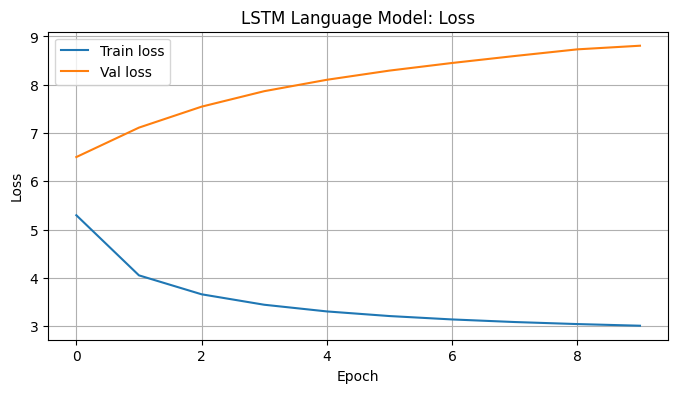

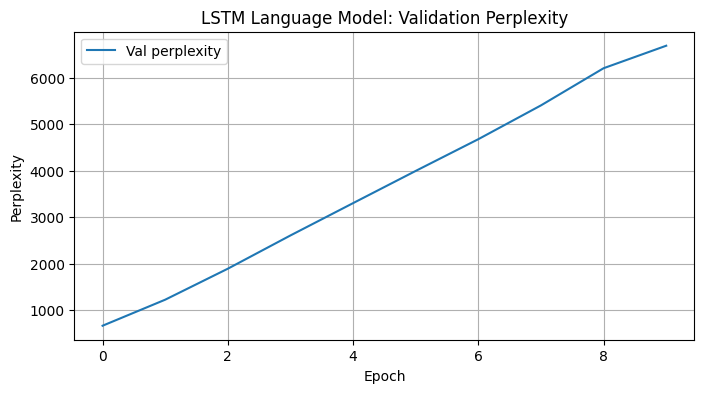

In [5]:
# Этап 2. Реализация и обучение LSTM
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 10
CLIP_VALUE = 1.0


# -----------------------------
# LSTM Language Model
# -----------------------------
class LSTMLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids):
        # input_ids: (batch_size, seq_len)
        x = self.embedding(input_ids)      # (batch_size, seq_len, embedding_dim)
        x, _ = self.lstm(x)                # (batch_size, seq_len, hidden_dim)
        logits = self.fc(x)                # (batch_size, seq_len, vocab_size)

        return logits


# -----------------------------
# Вспомогательные функции
# -----------------------------
def get_targets_from_batch(batch):
    if "target_ids" in batch:
        return batch["target_ids"]
    if "target" in batch:
        return batch["target"]
    raise KeyError("В batch нет ключа 'target_ids' или 'target'")


def calculate_loss(logits, targets, criterion):
    # logits:  (batch_size, seq_len, vocab_size)
    # targets: (batch_size, seq_len)

    vocab_size = logits.shape[-1]

    logits_flat = logits.reshape(-1, vocab_size)
    targets_flat = targets.reshape(-1)

    loss = criterion(logits_flat, targets_flat)

    return loss


def evaluate_lstm(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            targets = get_targets_from_batch(batch).to(device)

            logits = model(input_ids)
            loss = calculate_loss(logits, targets, criterion)

            n_tokens = targets.numel()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# -----------------------------
# Создание модели
# -----------------------------
lstm_model = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=0.2
).to(device)

print("Vocab size:", VOCAB_SIZE)
print("Trainable params:", count_parameters(lstm_model))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR)


# -----------------------------
# Обучение
# -----------------------------
history_lstm = {
    "train_loss": [],
    "val_loss": [],
    "val_ppl": [],
    "epoch_time": []
}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    lstm_model.train()

    total_train_loss = 0.0
    total_train_tokens = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        targets = get_targets_from_batch(batch).to(device)

        optimizer.zero_grad()

        logits = lstm_model(input_ids)
        loss = calculate_loss(logits, targets, criterion)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), CLIP_VALUE)

        optimizer.step()

        n_tokens = targets.numel()
        total_train_loss += loss.item() * n_tokens
        total_train_tokens += n_tokens

    train_loss = total_train_loss / total_train_tokens

    val_loss, val_ppl = evaluate_lstm(
        lstm_model,
        val_loader,
        criterion,
        device
    )

    epoch_time = time.time() - t0

    history_lstm["train_loss"].append(train_loss)
    history_lstm["val_loss"].append(val_loss)
    history_lstm["val_ppl"].append(val_ppl)
    history_lstm["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_ppl={val_ppl:.2f} | "
        f"time={epoch_time:.2f}s"
    )


# -----------------------------
# Графики обучения
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(history_lstm["train_loss"], label="Train loss")
plt.plot(history_lstm["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Language Model: Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history_lstm["val_ppl"], label="Val perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("LSTM Language Model: Validation Perplexity")
plt.legend()
plt.grid(True)
plt.show()

Device: cuda
GRU params: 15658845
Epoch 01/10 | train_loss=4.9021 | val_loss=6.4122 | val_ppl=609.25 | time=168.17s
Epoch 02/10 | train_loss=3.8255 | val_loss=6.7884 | val_ppl=887.53 | time=168.47s
Epoch 03/10 | train_loss=3.5180 | val_loss=7.0530 | val_ppl=1156.31 | time=168.33s
Epoch 04/10 | train_loss=3.3436 | val_loss=7.2567 | val_ppl=1417.53 | time=168.45s
Epoch 05/10 | train_loss=3.2290 | val_loss=7.4148 | val_ppl=1660.32 | time=168.33s
Epoch 06/10 | train_loss=3.1471 | val_loss=7.5318 | val_ppl=1866.44 | time=168.29s
Epoch 07/10 | train_loss=3.0846 | val_loss=7.6286 | val_ppl=2056.07 | time=168.28s
Epoch 08/10 | train_loss=3.0354 | val_loss=7.7179 | val_ppl=2248.13 | time=168.40s
Epoch 09/10 | train_loss=2.9945 | val_loss=7.7862 | val_ppl=2407.11 | time=168.32s
Epoch 10/10 | train_loss=2.9606 | val_loss=7.8589 | val_ppl=2588.78 | time=168.37s

Сравнение моделей:


,model,params,best_val_ppl,last_val_ppl,avg_epoch_time_sec
0,LSTM,15889245,666.412560,6683.010291,168.793630
1,GRU,15658845,609.250876,2588.778689,168.341125


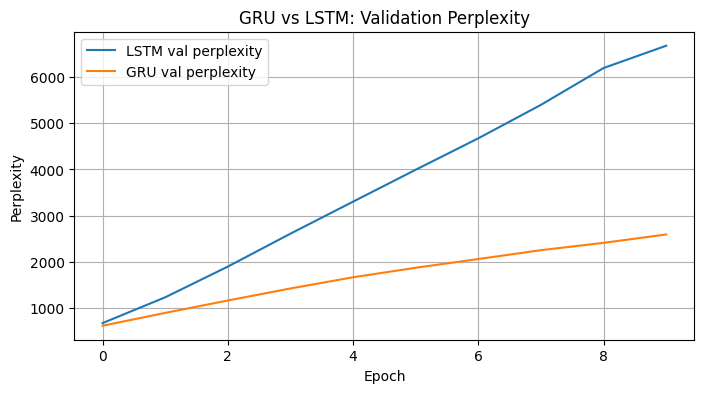

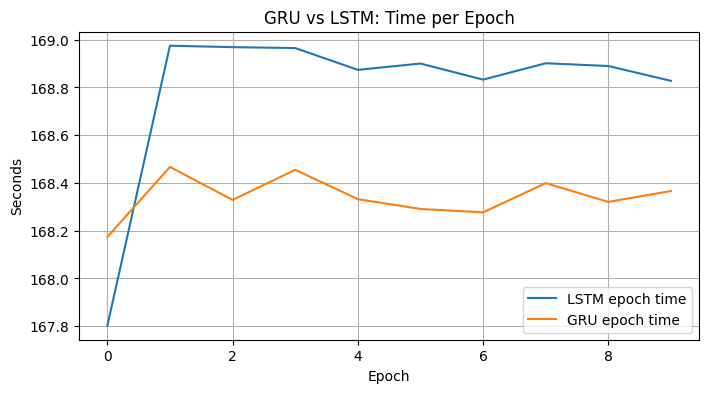


Выводы:
- GRU имеет меньше параметров, чем LSTM. Это хорошо для мобильного устройства.
- GRU обучается быстрее по среднему времени эпохи.
- GRU показал лучшую минимальную val perplexity.
- Для мобильного мессенджера GRU может быть предпочтительнее, если качество близко к LSTM, потому что GRU проще и обычно легче по параметрам.


In [6]:
# Этап 3. Эксперимент: GRU vs LSTM
# -----------------------------
# Настройки
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

VOCAB_SIZE = len(vocab)

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 10
CLIP_VALUE = 1.0


# -----------------------------
# GRU Language Model
# -----------------------------
class GRULanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)      # (batch_size, seq_len, embedding_dim)
        x, _ = self.gru(x)                 # (batch_size, seq_len, hidden_dim)
        logits = self.fc(x)                # (batch_size, seq_len, vocab_size)

        return logits


# -----------------------------
# Общие функции
# -----------------------------
def get_targets_from_batch(batch):
    if "target_ids" in batch:
        return batch["target_ids"]
    if "target" in batch:
        return batch["target"]
    raise KeyError("В batch нет ключа 'target_ids' или 'target'")


def calculate_loss(logits, targets, criterion):
    vocab_size = logits.shape[-1]

    logits_flat = logits.reshape(-1, vocab_size)
    targets_flat = targets.reshape(-1)

    return criterion(logits_flat, targets_flat)


def evaluate_language_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            targets = get_targets_from_batch(batch).to(device)

            logits = model(input_ids)
            loss = calculate_loss(logits, targets, criterion)

            n_tokens = targets.numel()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_language_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    clip_value=1.0,
    device="cpu"
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_ppl": [],
        "epoch_time": []
    }

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()

        total_train_loss = 0.0
        total_train_tokens = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            targets = get_targets_from_batch(batch).to(device)

            optimizer.zero_grad()

            logits = model(input_ids)
            loss = calculate_loss(logits, targets, criterion)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

            optimizer.step()

            n_tokens = targets.numel()
            total_train_loss += loss.item() * n_tokens
            total_train_tokens += n_tokens

        train_loss = total_train_loss / total_train_tokens

        val_loss, val_ppl = evaluate_language_model(
            model,
            val_loader,
            criterion,
            device
        )

        epoch_time = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_ppl={val_ppl:.2f} | "
            f"time={epoch_time:.2f}s"
        )

    return history


# -----------------------------
# Обучение GRU
# -----------------------------
gru_model = GRULanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=0.2
)

print("GRU params:", count_parameters(gru_model))

history_gru = train_language_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    clip_value=CLIP_VALUE,
    device=device
)


# -----------------------------
# Сравнение GRU vs LSTM
# -----------------------------
gru_best_ppl = min(history_gru["val_ppl"])
gru_last_ppl = history_gru["val_ppl"][-1]
gru_avg_time = sum(history_gru["epoch_time"]) / len(history_gru["epoch_time"])
gru_params = count_parameters(gru_model)

# Берём LSTM из предыдущего этапа
lstm_best_ppl = min(history_lstm["val_ppl"])
lstm_last_ppl = history_lstm["val_ppl"][-1]
lstm_avg_time = sum(history_lstm["epoch_time"]) / len(history_lstm["epoch_time"])
lstm_params = count_parameters(lstm_model)

comparison_df = pd.DataFrame([
    {
        "model": "LSTM",
        "params": lstm_params,
        "best_val_ppl": lstm_best_ppl,
        "last_val_ppl": lstm_last_ppl,
        "avg_epoch_time_sec": lstm_avg_time,
    },
    {
        "model": "GRU",
        "params": gru_params,
        "best_val_ppl": gru_best_ppl,
        "last_val_ppl": gru_last_ppl,
        "avg_epoch_time_sec": gru_avg_time,
    },
])

print("\nСравнение моделей:")
display(comparison_df)


# -----------------------------
# Графики сравнения
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(history_lstm["val_ppl"], label="LSTM val perplexity")
plt.plot(history_gru["val_ppl"], label="GRU val perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("GRU vs LSTM: Validation Perplexity")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(history_lstm["epoch_time"], label="LSTM epoch time")
plt.plot(history_gru["epoch_time"], label="GRU epoch time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("GRU vs LSTM: Time per Epoch")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Выводы
# -----------------------------
print("\nВыводы:")

if gru_params < lstm_params:
    print("- GRU имеет меньше параметров, чем LSTM. Это хорошо для мобильного устройства.")
else:
    print("- GRU не оказался меньше LSTM по числу параметров в этой конфигурации.")

if gru_avg_time < lstm_avg_time:
    print("- GRU обучается быстрее по среднему времени эпохи.")
else:
    print("- LSTM обучается быстрее по среднему времени эпохи.")

if gru_best_ppl < lstm_best_ppl:
    print("- GRU показал лучшую минимальную val perplexity.")
else:
    print("- LSTM показал лучшую минимальную val perplexity.")

print(
    "- Для мобильного мессенджера GRU может быть предпочтительнее, "
    "если качество близко к LSTM, потому что GRU проще и обычно легче по параметрам."
)

In [7]:
# Этап 4. Оценка distilgpt2
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

# -----------------------------
# Настройки
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MODEL_NAME = "distilgpt2"
MAX_LENGTH = 128          # ограничиваем длину, чтобы не было слишком долго
MAX_EVAL_TEXTS = 300      # для ускорения можно уменьшить/увеличить

# -----------------------------
# Загрузка модели и токенизатора
# -----------------------------
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
model_distilgpt2 = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)

# У GPT-2 нет pad_token по умолчанию, используем eos_token
tokenizer.pad_token = tokenizer.eos_token
model_distilgpt2.eval()

print("Модель загружена:", MODEL_NAME)

# -----------------------------
# Подготовка тестовых текстов
# -----------------------------
distilgpt2_test_texts = [
    text for text in test_texts
    if isinstance(text, str) and len(text.strip()) > 0
]

distilgpt2_test_texts = distilgpt2_test_texts[:MAX_EVAL_TEXTS]

print("Текстов для оценки:", len(distilgpt2_test_texts))

# -----------------------------
# Расчёт perplexity
# -----------------------------
total_loss = 0.0
total_tokens = 0

t0 = time.time()

with torch.no_grad():
    for text in distilgpt2_test_texts:
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        # слишком короткие тексты пропускаем
        if input_ids.shape[1] < 2:
            continue

        outputs = model_distilgpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )

        loss = outputs.loss

        n_tokens = attention_mask.sum().item()

        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

avg_loss = total_loss / total_tokens
distilgpt2_ppl = math.exp(avg_loss)

elapsed = time.time() - t0

print("\ndistilgpt2 test loss:", round(avg_loss, 4))
print("distilgpt2 test perplexity:", round(distilgpt2_ppl, 2))
print("Время оценки:", round(elapsed, 2), "сек.")


# -----------------------------
# Функция предсказания следующего слова/токена
# -----------------------------
def predict_distilgpt2_next(context, top_k=5):
    encoded = tokenizer(
        context,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model_distilgpt2(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)

    predictions = []

    for prob, token_id in zip(top_probs[0], top_ids[0]):
        token = tokenizer.decode([token_id.item()])
        predictions.append((token, prob.item()))

    return predictions


# -----------------------------
# Примеры предсказаний
# -----------------------------
examples = [
    "the president of the",
    "i want to",
    "the weather today is",
    "new york is a",
    "the main problem with this approach is",
    "in the middle of the night",
]

print("\nПримеры предсказаний distilgpt2:")

for context in examples:
    preds = predict_distilgpt2_next(context, top_k=5)

    print("\nКонтекст:", context)
    print("Top-5 предсказаний:")

    for token, prob in preds:
        print(f"  {repr(token):>12} | prob={prob:.4f}")

Device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Модель загружена: distilgpt2
Текстов для оценки: 300


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



distilgpt2 test loss: 4.5224
distilgpt2 test perplexity: 92.06
Время оценки: 0.53 сек.

Примеры предсказаний distilgpt2:

Контекст: the president of the
Top-5 предсказаний:
     ' United' | prob=0.6016
          ' U' | prob=0.0372
         ' US' | prob=0.0232
   ' European' | prob=0.0119
      ' world' | prob=0.0108

Контекст: i want to
Top-5 предсказаний:
         ' be' | prob=0.0565
        ' see' | prob=0.0553
       ' make' | prob=0.0415
         ' do' | prob=0.0411
       ' know' | prob=0.0408

Контекст: the weather today is
Top-5 предсказаний:
          ' a' | prob=0.0514
        ' the' | prob=0.0445
       ' very' | prob=0.0347
        ' not' | prob=0.0265
      ' going' | prob=0.0229

Контекст: new york is a
Top-5 предсказаний:
       ' very' | prob=0.0183
        ' new' | prob=0.0182
      ' great' | prob=0.0177
       ' good' | prob=0.0110
        ' bit' | prob=0.0089

Контекст: the main problem with this approach is
Top-5 предсказаний:
       ' that' | prob=0.6945
        '

In [8]:
# Этап 5. Сравнение и выводы
# -----------------------------
# Общие настройки
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

criterion = nn.CrossEntropyLoss()


# -----------------------------
# Вспомогательные функции
# -----------------------------
def get_targets_from_batch(batch):
    if "target_ids" in batch:
        return batch["target_ids"]
    if "target" in batch:
        return batch["target"]
    raise KeyError("В batch нет ключа 'target_ids' или 'target'")


def calculate_loss(logits, targets, criterion):
    vocab_size = logits.shape[-1]
    logits_flat = logits.reshape(-1, vocab_size)
    targets_flat = targets.reshape(-1)
    return criterion(logits_flat, targets_flat)


def evaluate_language_model(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            targets = get_targets_from_batch(batch).to(device)

            logits = model(input_ids)
            loss = calculate_loss(logits, targets, criterion)

            n_tokens = targets.numel()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    return avg_loss, ppl


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def safe_mean(values):
    return sum(values) / len(values) if len(values) > 0 else None


# -----------------------------
# Test perplexity для LSTM и GRU
# -----------------------------
lstm_test_loss, lstm_test_ppl = evaluate_language_model(
    lstm_model.to(device),
    test_loader,
    criterion,
    device
)

gru_test_loss, gru_test_ppl = evaluate_language_model(
    gru_model.to(device),
    test_loader,
    criterion,
    device
)


# -----------------------------
# Test perplexity для distilgpt2
# Если distilgpt2 уже считался на этапе 4, используем готовое значение.
# Если нет — считаем заново на ограниченном числе текстов.
# -----------------------------
if "distilgpt2_ppl" not in globals():
    MAX_LENGTH = 128
    MAX_EVAL_TEXTS = 300

    distilgpt2_test_texts = [
        text for text in test_texts
        if isinstance(text, str) and len(text.strip()) > 0
    ][:MAX_EVAL_TEXTS]

    total_loss = 0.0
    total_tokens = 0

    model_distilgpt2.eval()

    with torch.no_grad():
        for text in distilgpt2_test_texts:
            encoded = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH
            )

            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)

            if input_ids.shape[1] < 2:
                continue

            outputs = model_distilgpt2(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )

            n_tokens = attention_mask.sum().item()
            total_loss += outputs.loss.item() * n_tokens
            total_tokens += n_tokens

    distilgpt2_loss = total_loss / total_tokens
    distilgpt2_ppl = math.exp(distilgpt2_loss)


# -----------------------------
# Сводная таблица
# -----------------------------
results_df = pd.DataFrame([
    {
        "model": "LSTM",
        "params": count_parameters(lstm_model),
        "val_perplexity": min(history_lstm["val_ppl"]),
        "test_perplexity": lstm_test_ppl,
        "avg_epoch_time_sec": safe_mean(history_lstm["epoch_time"]),
    },
    {
        "model": "GRU",
        "params": count_parameters(gru_model),
        "val_perplexity": min(history_gru["val_ppl"]),
        "test_perplexity": gru_test_ppl,
        "avg_epoch_time_sec": safe_mean(history_gru["epoch_time"]),
    },
    {
        "model": "distilgpt2",
        "params": count_parameters(model_distilgpt2),
        "val_perplexity": None,
        "test_perplexity": distilgpt2_ppl,
        "avg_epoch_time_sec": None,
    },
])

print("Сводная таблица результатов:")
display(results_df)


# -----------------------------
# Предсказания LSTM / GRU
# -----------------------------
def predict_rnn_next_word(model, context, vocab, id_to_word, top_k=5):
    model.eval()

    tokens = tokenize(context)
    token_ids = [vocab.get(token, UNK_ID) for token in tokens]

    if len(token_ids) == 0:
        token_ids = [UNK_ID]

    # Берём последние SEQ_LEN токенов
    token_ids = token_ids[-SEQ_LEN:]

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids)

        # Берём предсказание для последней позиции
        last_logits = logits[:, -1, :]
        probs = torch.softmax(last_logits, dim=-1)

        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)

    predictions = []

    for prob, token_id in zip(top_probs[0], top_ids[0]):
        word = id_to_word.get(int(token_id.item()), "<UNK>")
        predictions.append((word, float(prob.item())))

    return predictions


# -----------------------------
# Предсказания distilgpt2
# -----------------------------
def predict_distilgpt2_next_word(context, top_k=5):
    model_distilgpt2.eval()

    encoded = tokenizer(
        context,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model_distilgpt2(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)

    predictions = []

    for prob, token_id in zip(top_probs[0], top_ids[0]):
        token = tokenizer.decode([token_id.item()])
        predictions.append((token, float(prob.item())))

    return predictions


# -----------------------------
# Примеры на одинаковых контекстах
# -----------------------------
contexts = [
    "the president of the",
    "i want to",
    "the weather today is",
    "new york is a",
    "the main problem with this approach is",
    "in the middle of the",
    "the company announced that",
    "this article describes the",
]

print("\nПримеры предсказаний всех моделей:")

for context in contexts:
    lstm_preds = predict_rnn_next_word(
        lstm_model,
        context,
        vocab,
        id_to_word,
        top_k=3
    )

    gru_preds = predict_rnn_next_word(
        gru_model,
        context,
        vocab,
        id_to_word,
        top_k=3
    )

    distil_preds = predict_distilgpt2_next_word(
        context,
        top_k=3
    )

    print("\nКонтекст:", repr(context))

    print("LSTM:")
    for word, prob in lstm_preds:
        print(f"  {word:>15} | prob={prob:.4f}")

    print("GRU:")
    for word, prob in gru_preds:
        print(f"  {word:>15} | prob={prob:.4f}")

    print("distilgpt2:")
    for word, prob in distil_preds:
        print(f"  {repr(word):>15} | prob={prob:.4f}")


# -----------------------------
# Выводы и рекомендации
# -----------------------------
print("\nВыводы:")

best_val_row = results_df.dropna(subset=["val_perplexity"]).sort_values("val_perplexity").iloc[0]
best_test_row = results_df.sort_values("test_perplexity").iloc[0]

print(
    f"- Среди обученных с нуля моделей лучшая val perplexity у {best_val_row['model']}: "
    f"{best_val_row['val_perplexity']:.2f}."
)

print(
    f"- Лучшая test perplexity в таблице у {best_test_row['model']}: "
    f"{best_test_row['test_perplexity']:.2f}."
)

if count_parameters(gru_model) < count_parameters(lstm_model):
    print("- GRU компактнее LSTM по числу параметров, что важно для мобильного устройства.")

if safe_mean(history_gru["epoch_time"]) < safe_mean(history_lstm["epoch_time"]):
    print("- GRU быстрее LSTM по среднему времени эпохи.")
else:
    print("- В этом запуске LSTM оказался не медленнее GRU по времени эпохи.")

print(
    "- distilgpt2 обычно даёт более качественные предсказания, потому что это предобученный трансформер, "
    "но он значительно тяжелее LSTM/GRU и использует другой токенизатор, поэтому perplexity нельзя напрямую "
    "сравнивать один-в-один."
)

print("\nРекомендации для продакт-менеджера:")

print(
    "1. Для мобильной клавиатуры базовым кандидатом стоит рассматривать GRU, если его perplexity близка к LSTM: "
    "он проще, компактнее и обычно быстрее."
)

print(
    "2. LSTM имеет смысл оставить как более сильный baseline среди RNN: если он заметно лучше GRU по perplexity, "
    "можно использовать его, но проверить задержку инференса на устройстве."
)

print(
    "3. distilgpt2 полезен как верхняя планка качества и источник идей, но для мобильного продакшена его нужно "
    "сжимать: distillation, quantization, pruning или вынос инференса на сервер."
)

print(
    "4. Перед внедрением нужно сравнить модели не только по perplexity, но и по latency, размеру файла модели, "
    "потреблению памяти и качеству top-3 подсказок на реальных пользовательских фразах."
)

Device: cuda
Сводная таблица результатов:


,model,params,val_perplexity,test_perplexity,avg_epoch_time_sec
0,LSTM,15889245,666.412560,7356.123895,168.793630
1,GRU,15658845,609.250876,2615.223164,168.341125
2,distilgpt2,81912576,NaN,92.055728,NaN



Примеры предсказаний всех моделей:

Контекст: 'the president of the'
LSTM:
         republic | prob=0.4592
       federative | prob=0.0532
       university | prob=0.0364
GRU:
         republic | prob=0.3785
            state | prob=0.0418
          supreme | prob=0.0407
distilgpt2:
        ' United' | prob=0.6016
             ' U' | prob=0.0372
            ' US' | prob=0.0232

Контекст: 'i want to'
LSTM:
               do | prob=0.1343
                i | prob=0.1235
              use | prob=0.1146
GRU:
               do | prob=0.1005
               be | prob=0.0945
             have | prob=0.0919
distilgpt2:
            ' be' | prob=0.0565
           ' see' | prob=0.0553
          ' make' | prob=0.0415

Контекст: 'the weather today is'
LSTM:
              the | prob=0.1321
                a | prob=0.1117
             more | prob=0.0317
GRU:
                a | prob=0.0948
              the | prob=0.0715
         affected | prob=0.0450
distilgpt2:
             ' a' | prob=0.0514
    